# Phase 2.5 Experiment: Dataset Limitation Profiling and Reliability Examination

This notebook prototypes the examination-only Phase 2.5 layer. It identifies dataset-property risks before mitigation decisions are made.

**Guardrail:** this notebook does not remove tweets, correct sentiment, invert sarcasm, route models, choose a winning model, or finalize mitigation. It writes diagnostic evidence only.

## Stage map

```text
Phase 2 cleaned Twitter data
    -> Phase 2.5 dataset limitation profiling
    -> tweet-level 0-1 risk scores
    -> aggregate diagnostics, figures, and pending mitigation register
    -> later Phase 3, Phase 4, and Phase 5 decisions
```

The default run mode uses a bounded sample for quick evaluation. Set `RUN_FULL_DATASET = True` in the next cell when you are ready to produce full-dataset notebook artifacts.

In [10]:
from __future__ import annotations

from pathlib import Path
import hashlib
import json
import math
import re
import sys
from typing import Dict, Iterable, List, Optional, Tuple

import matplotlib
import numpy as np
import pandas as pd
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, Markdown, display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 80)


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from the project root or notebooks directory.')


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RUN_FULL_DATASET = False
SAMPLE_SIZE = 50000
RANDOM_SEED = 2020
USE_PHASE3_SENTIMENT_IF_AVAILABLE = True
INCLUDE_PHASE3_VALIDATION_SAMPLE = True

CLEANED_PATH = ROOT / 'data' / '02_interim' / 'twitter_cleaned.parquet'
SENTIMENT_PATH = ROOT / 'data' / '02_interim' / 'twitter_sentiment.parquet'
VALIDATION_SAMPLE_PATH = ROOT / 'output' / 'results' / 'phase3' / 'sentiment_validation_sample.parquet'
EVENTS_PATH = ROOT / 'data' / '02_interim' / 'political_events.parquet'

DATA_DIR = ROOT / 'data' / '02_5_reliability'
RESULTS_DIR = ROOT / 'output' / 'results' / 'phase2_5'
REPORTS_DIR = ROOT / 'output' / 'reports' / 'phase2_5'
GRAPHS_DIR = ROOT / 'output' / 'graphs' / 'phase2_5'
for directory in (DATA_DIR, RESULTS_DIR, REPORTS_DIR, GRAPHS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f'Project root: {ROOT}')
print(f'Run full dataset: {RUN_FULL_DATASET}')

Project root: d:\GW_UNIVERSITY\AIS\Social_Listener\Env\Social_Listener_V1\UOG_AIS_SOCIAL_LISTENER
Run full dataset: False


## Helper functions

These helpers are intentionally plain so they can be moved into `src/phase2_5_reliability/` later.

In [11]:
def choose_column(columns: Iterable[str], candidates: Iterable[str]) -> Optional[str]:
    available = set(columns)
    for candidate in candidates:
        if candidate in available:
            return candidate
    return None


def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    numerator = pd.to_numeric(numerator, errors='coerce')
    denominator = pd.to_numeric(denominator, errors='coerce').replace(0, np.nan)
    return (numerator / denominator).replace([np.inf, -np.inf], np.nan).fillna(0.0)


def percentile_rank(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors='coerce')
    if values.notna().sum() == 0:
        return pd.Series(np.nan, index=series.index, dtype='float64')
    if values.nunique(dropna=True) <= 1:
        return pd.Series(0.0, index=series.index, dtype='float64')
    return values.rank(method='average', pct=True).clip(0.0, 1.0)


def clip01(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors='coerce').clip(0.0, 1.0)


def row_mean(dataframe: pd.DataFrame, columns: Iterable[str]) -> pd.Series:
    existing = [column for column in columns if column in dataframe.columns]
    if not existing:
        return pd.Series(np.nan, index=dataframe.index, dtype='float64')
    return dataframe[existing].apply(pd.to_numeric, errors='coerce').mean(axis=1, skipna=True).clip(0.0, 1.0)


def bool_to_float(series: pd.Series) -> pd.Series:
    return series.fillna(False).astype(bool).astype(float)


def pattern_count(series: pd.Series, pattern: str, flags: int = re.IGNORECASE) -> pd.Series:
    compiled = re.compile(pattern, flags=flags)
    return series.fillna('').astype(str).map(lambda value: len(compiled.findall(value)))


def contains_pattern(series: pd.Series, pattern: str, flags: int = re.IGNORECASE) -> pd.Series:
    compiled = re.compile(pattern, flags=flags)
    return series.fillna('').astype(str).map(lambda value: bool(compiled.search(value)))


def normalize_content(series: pd.Series) -> pd.Series:
    normalized = series.fillna('').astype(str).str.lower()
    normalized = normalized.str.replace(r'https?://\S+|www\.\S+', ' ', regex=True)
    normalized = normalized.str.replace(r'@\w+', '@user', regex=True)
    normalized = normalized.str.replace(r'\s+', ' ', regex=True).str.strip()
    return normalized


def content_hash(series: pd.Series) -> pd.Series:
    return series.fillna('').astype(str).map(lambda value: hashlib.md5(value.encode('utf-8')).hexdigest())


def gini(values: pd.Series) -> float:
    array = pd.to_numeric(values, errors='coerce').dropna().to_numpy(dtype=float)
    if len(array) == 0 or np.all(array == 0):
        return 0.0
    array = np.sort(array)
    index = np.arange(1, len(array) + 1)
    return float((2 * np.sum(index * array) / (len(array) * np.sum(array))) - ((len(array) + 1) / len(array)))


def risk_tier(value: float) -> str:
    if pd.isna(value):
        return 'unavailable'
    if value < 0.25:
        return 'low'
    if value < 0.50:
        return 'moderate'
    if value < 0.75:
        return 'high'
    return 'severe'


def markdown_table(dataframe: pd.DataFrame, max_rows: int = 200) -> str:
    if dataframe.empty:
        return '_No records._'
    view = dataframe.head(max_rows).copy()
    view = view.astype(object).where(pd.notna(view), '')
    columns = [str(column) for column in view.columns]
    lines = [
        '| ' + ' | '.join(columns) + ' |',
        '| ' + ' | '.join(['---'] * len(columns)) + ' |',
    ]
    for _, row in view.iterrows():
        values = [str(row[column]).replace('|', '\\|').replace('\n', ' ') for column in view.columns]
        lines.append('| ' + ' | '.join(values) + ' |')
    if len(dataframe) > max_rows:
        lines.append(f'\n_Table truncated to {max_rows} of {len(dataframe)} rows._')
    return '\n'.join(lines)

## Load data and infer schema

The notebook prefers `twitter_sentiment.parquet` when it exists because VADER fields support richer diagnostics. Set `USE_PHASE3_SENTIMENT_IF_AVAILABLE = False` for a strict pre-Phase-3 run.

In [12]:
source_path = SENTIMENT_PATH if USE_PHASE3_SENTIMENT_IF_AVAILABLE and SENTIMENT_PATH.exists() else CLEANED_PATH
if not source_path.exists():
    raise FileNotFoundError(f'Missing input dataset: {source_path}')

source_df = pd.read_parquet(source_path)
if RUN_FULL_DATASET:
    evaluation_df = source_df.copy()
else:
    evaluation_df = source_df.sample(n=min(SAMPLE_SIZE, len(source_df)), random_state=RANDOM_SEED).copy()

validation_df = None
if INCLUDE_PHASE3_VALIDATION_SAMPLE and VALIDATION_SAMPLE_PATH.exists():
    validation_df = pd.read_parquet(VALIDATION_SAMPLE_PATH)
    evaluation_df = pd.concat([evaluation_df, validation_df], ignore_index=True, sort=False)

column_map = {
    'tweet_id': choose_column(evaluation_df.columns, ['id', 'tweet_id', 'status_id']),
    'text': choose_column(evaluation_df.columns, ['tweet', 'cleaned_tweet', 'text', 'full_text']),
    'timestamp': choose_column(evaluation_df.columns, ['date', 'created_at', 'timestamp', 'datetime']),
    'user_id': choose_column(evaluation_df.columns, ['user_id', 'author_id', 'username']),
    'user_location': choose_column(evaluation_df.columns, ['user_loc', 'user_location', 'location']),
    'candidate': choose_column(evaluation_df.columns, ['candidate', 'candidate_stream', 'target_candidate']),
}

required_missing = [name for name in ['text', 'timestamp', 'user_id'] if column_map[name] is None]
if required_missing:
    raise ValueError(f'Required columns could not be inferred: {required_missing}')

if column_map['tweet_id'] is not None:
    evaluation_df = evaluation_df.drop_duplicates(subset=[column_map['tweet_id']], keep='last').reset_index(drop=True)
else:
    evaluation_df = evaluation_df.reset_index(drop=True)
    evaluation_df['_phase2_5_row_id'] = evaluation_df.index.astype(str)
    column_map['tweet_id'] = '_phase2_5_row_id'

schema_manifest = {
    'phase': 'phase2_5_dataset_limitation_examination',
    'status': 'notebook_prototype',
    'source_path': str(source_path),
    'run_full_dataset': RUN_FULL_DATASET,
    'source_record_count': int(len(source_df)),
    'evaluated_record_count': int(len(evaluation_df)),
    'phase3_validation_sample_included': validation_df is not None,
    'column_map': column_map,
    'available_columns': list(evaluation_df.columns),
    'missing_optional_fields': [
        field for field, column in column_map.items() if column is None
    ],
    'mitigation_status': 'pending',
    'scope_note': 'Notebook diagnostics only; no mitigation, filtering, model correction, or weighting applied.',
}
(DATA_DIR / 'phase2_5_schema_manifest.json').write_text(json.dumps(schema_manifest, indent=2), encoding='utf-8')

display(pd.DataFrame([{
    'source_path': source_path.relative_to(ROOT).as_posix(),
    'source_rows': len(source_df),
    'evaluated_rows': len(evaluation_df),
    'full_run': RUN_FULL_DATASET,
    'validation_sample_included': validation_df is not None,
}]))
display(pd.DataFrame([column_map]))

,source_path,source_rows,evaluated_rows,full_run,validation_sample_included
0,data/02_interim/twitter_sentiment.parquet,1331317,54812,False,True


,tweet_id,text,timestamp,user_id,user_location,candidate
0,id,tweet,date,user_id,user_loc,candidate


## Criterion profilers

Each profiler returns indicators and one or more 0-1 scores. These scores are provisional and diagnostic.

In [13]:
EMOJI_PATTERN = re.compile('[\U0001F300-\U0001FAFF\u2600-\u27BF]')


def profile_textual_usability(dataframe: pd.DataFrame, text_col: str) -> pd.DataFrame:
    text = dataframe[text_col].fillna('').astype(str)
    result = pd.DataFrame(index=dataframe.index)
    result['word_count'] = text.str.count(r'\b\w+\b')
    result['character_count'] = text.str.len()
    result['hashtag_count'] = text.str.count(r'#\w+')
    result['mention_count'] = text.str.count(r'@\w+')
    result['url_count'] = text.str.count(r'https?://\S+|www\.\S+')
    result['emoji_count'] = text.map(lambda value: len(EMOJI_PATTERN.findall(value)))
    result['punctuation_count'] = text.str.count(r'[^\w\s#@]')
    alpha_count = text.str.count(r'[A-Za-z]')
    uppercase_count = text.str.count(r'[A-Z]')
    result['uppercase_char_ratio'] = safe_divide(uppercase_count, alpha_count)
    result['hashtag_ratio'] = safe_divide(result['hashtag_count'], result['word_count'])
    result['mention_ratio'] = safe_divide(result['mention_count'], result['word_count'])
    result['url_ratio'] = safe_divide(result['url_count'], result['word_count'])
    result['emoji_ratio'] = safe_divide(result['emoji_count'], result['word_count'])
    result['punctuation_intensity'] = safe_divide(result['punctuation_count'], result['character_count'])
    result['non_alphabetic_ratio'] = 1.0 - safe_divide(alpha_count, result['character_count'])
    stripped = text.str.strip()
    result['is_empty_text'] = stripped.eq('')
    result['is_url_only'] = stripped.str.fullmatch(r'(https?://\S+|www\.\S+)(\s+(https?://\S+|www\.\S+))*', na=False)
    without_hash = stripped.str.replace(r'#\w+', ' ', regex=True).str.replace(r'[^A-Za-z0-9]+', ' ', regex=True).str.strip()
    without_mentions = stripped.str.replace(r'@\w+', ' ', regex=True).str.replace(r'[^A-Za-z0-9]+', ' ', regex=True).str.strip()
    result['is_hashtag_only'] = result['hashtag_count'].gt(0) & without_hash.eq('')
    result['is_mention_only'] = result['mention_count'].gt(0) & without_mentions.eq('')
    result['is_extremely_short'] = result['word_count'].le(3)
    result['text_sparsity_risk'] = (1.0 - (result['word_count'] / 12.0)).clip(0.0, 1.0)
    result['hashtag_dominance_risk'] = percentile_rank(result['hashtag_ratio'])
    result['url_dominance_risk'] = percentile_rank(result['url_ratio']).fillna(0.0)
    result['mention_dominance_risk'] = percentile_rank(result['mention_ratio'])
    result['emoji_dominance_risk'] = percentile_rank(result['emoji_ratio'])
    result['punctuation_intensity_risk'] = percentile_rank(result['punctuation_intensity'])
    if 'detected_language' in dataframe.columns:
        language = dataframe['detected_language'].astype('string').str.lower()
        result['language_mismatch_risk'] = pd.Series(np.where(language.isna(), 0.5, np.where(language.eq('en').fillna(False), 0.0, 1.0)), index=dataframe.index)
    else:
        ascii_ratio = safe_divide(text.str.count(r'[A-Za-z]'), alpha_count.replace(0, np.nan))
        result['language_mismatch_risk'] = (1.0 - ascii_ratio).clip(0.0, 1.0).fillna(0.5)
    result['textual_usability_risk'] = row_mean(result, [
        'text_sparsity_risk', 'hashtag_dominance_risk', 'url_dominance_risk',
        'mention_dominance_risk', 'emoji_dominance_risk', 'punctuation_intensity_risk',
        'language_mismatch_risk',
    ])
    return result


def profile_sentiment_ambiguity(dataframe: pd.DataFrame, text_col: str) -> pd.DataFrame:
    text = dataframe[text_col].fillna('').astype(str)
    lower = text.str.lower()
    result = pd.DataFrame(index=dataframe.index)
    result['question_mark_count'] = text.str.count(r'\?')
    result['exclamation_count'] = text.str.count(r'!')
    result['quote_count'] = text.str.count(r'[\"\'\u201c\u201d\u2018\u2019]')
    result['contains_contrast_marker'] = contains_pattern(text, r'\b(but|however|although|though|yet|still|despite|whereas)\b')
    result['contains_uncertainty_marker'] = contains_pattern(text, r'\b(maybe|perhaps|apparently|seems|seem|unclear|not sure|could|might|possibly)\b')
    result['contains_negation'] = contains_pattern(text, r'\b(no|not|never|none|nothing|neither|nor|cannot|can\'t|don\'t|doesn\'t|didn\'t|isn\'t|wasn\'t)\b')
    trump_mentions = lower.str.count(r'\b(trump|donald|maga|potus)\b')
    biden_mentions = lower.str.count(r'\b(biden|joe|kamala|harris)\b')
    result['target_candidate_count'] = trump_mentions.gt(0).astype(int) + biden_mentions.gt(0).astype(int)
    result['candidate_mention_balance'] = (trump_mentions.gt(0) & biden_mentions.gt(0)).astype(float)
    word_count = text.str.count(r'\b\w+\b')
    result['short_ambiguous_phrase_flag'] = word_count.le(5) & (result['question_mark_count'].gt(0) | result['target_candidate_count'].gt(0))
    proxy_columns = [
        'contains_contrast_marker', 'contains_uncertainty_marker', 'contains_negation',
        'candidate_mention_balance', 'short_ambiguous_phrase_flag',
    ]
    for column in proxy_columns:
        result[f'{column}_risk'] = bool_to_float(result[column])
    result['question_intensity_risk'] = percentile_rank(result['question_mark_count'])
    result['text_proxy_ambiguity_risk'] = row_mean(result, [f'{column}_risk' for column in proxy_columns] + ['question_intensity_risk'])
    if 'vader_compound' in dataframe.columns:
        result['vader_abs_compound'] = dataframe['vader_compound'].abs()
        result['vader_uncertainty_risk'] = (1.0 - result['vader_abs_compound']).clip(0.0, 1.0)
    if 'vader_neutral' in dataframe.columns:
        result['neutral_dominance_risk'] = clip01(dataframe['vader_neutral'])
    probability_columns = ['roberta_negative_probability', 'roberta_neutral_probability', 'roberta_positive_probability']
    if all(column in dataframe.columns for column in probability_columns):
        probabilities = dataframe[probability_columns].apply(pd.to_numeric, errors='coerce')
        valid_probabilities = probabilities.notna().all(axis=1)
        entropy = -(probabilities * np.log(probabilities.clip(lower=1e-12))).sum(axis=1) / math.log(3)
        entropy = entropy.where(valid_probabilities)
        sorted_probabilities = np.sort(probabilities.fillna(0.0).to_numpy(), axis=1)
        gap = sorted_probabilities[:, -1] - sorted_probabilities[:, -2]
        result['roberta_entropy'] = entropy.clip(0.0, 1.0)
        result['model_confidence_gap'] = gap
        result['model_uncertainty_risk'] = (1.0 - pd.Series(gap, index=dataframe.index)).clip(0.0, 1.0).where(valid_probabilities)
    result['sentiment_ambiguity_risk'] = row_mean(result, [
        'text_proxy_ambiguity_risk', 'vader_uncertainty_risk', 'neutral_dominance_risk',
        'roberta_entropy', 'model_uncertainty_risk',
    ])
    return result


def profile_sarcasm_irony(dataframe: pd.DataFrame, text_col: str) -> pd.DataFrame:
    text = dataframe[text_col].fillna('').astype(str)
    result = pd.DataFrame(index=dataframe.index)
    result['sarcasm_keyword_count'] = pattern_count(text, r'\b(yeah right|sure|totally|as always|great job|nice job|brilliant move|what a guy|lol|lmao|lmfao|haha|ha ha|smh)\b')
    result['irony_marker_count'] = pattern_count(text, r'\b(lol|lmao|lmfao|haha|ha ha|sure jan|yeah right|smh)\b')
    result['eye_roll_emoji_flag'] = text.str.contains('\U0001F644', regex=False, na=False)
    result['positive_word_negative_context_flag'] = contains_pattern(text, r'\b(great|wonderful|amazing|brilliant|perfect|love|best|excellent|thanks|awesome|presidential)\b') & contains_pattern(text, r'\b(ruin|ruining|liar|lies|corrupt|nightmare|disaster|idiot|stupid|racist|fraud|loser|kill|killing|hate|worst|clown|evil|sucks)\b')
    result['negative_word_positive_context_flag'] = contains_pattern(text, r'\b(bad|terrible|awful|horrible|worst|sick|dead|crying|tears)\b') & contains_pattern(text, r'\b(love|great|best|win|winning|happy|proud|celebrating)\b')
    result['quotation_around_sentiment_word_flag'] = contains_pattern(text, r'[\"\u201c\u201d](great|winner|patriot|genius|leader|presidential|honest)[\"\u201c\u201d]')
    result['ellipsis_count'] = text.str.count(r'\.\.\.|\u2026')
    result['contrast_marker_count'] = pattern_count(text, r'\b(but|however|although|though|yet|still|despite|whereas)\b')
    rule_components = pd.DataFrame({
        'sarcasm_keywords': (result['sarcasm_keyword_count'] / 2.0).clip(0.0, 1.0),
        'irony_markers': (result['irony_marker_count'] / 2.0).clip(0.0, 1.0),
        'eye_roll': bool_to_float(result['eye_roll_emoji_flag']),
        'positive_negative_context': bool_to_float(result['positive_word_negative_context_flag']),
        'negative_positive_context': bool_to_float(result['negative_word_positive_context_flag']),
        'quoted_sentiment': bool_to_float(result['quotation_around_sentiment_word_flag']),
        'ellipsis': percentile_rank(result['ellipsis_count']).fillna(0.0),
        'contrast': percentile_rank(result['contrast_marker_count']).fillna(0.0),
    }, index=dataframe.index)
    result['rule_based_sarcasm_risk'] = rule_components.mean(axis=1).clip(0.0, 1.0)
    if 'vader_label' in dataframe.columns and 'roberta_label' in dataframe.columns:
        polarity = {'negative': -1, 'neutral': 0, 'positive': 1}
        vader = dataframe['vader_label'].map(polarity)
        roberta = dataframe['roberta_label'].map(polarity)
        result['vader_roberta_polarity_conflict'] = vader.mul(roberta).eq(-1)
        result['model_conflict_sarcasm_risk'] = bool_to_float(result['vader_roberta_polarity_conflict'])
    result['sarcasm_irony_risk'] = row_mean(result, ['rule_based_sarcasm_risk', 'model_conflict_sarcasm_risk'])
    return result

In [14]:
US_STATES = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming', 'DC': 'District of Columbia',
}
STATE_NAMES = {name.lower(): abbr for abbr, name in US_STATES.items()}
STATE_ABBR_PATTERN = re.compile(r'(^|[\s,;/|()\-])(' + '|'.join(sorted(US_STATES)) + r')($|[\s,;/|()\-])')
FICTIONAL_LOCATION_PATTERN = re.compile(r'\b(earth|moon|mars|universe|worldwide|internet|somewhere|nowhere|hell|heaven|maga country|kag country|home)\b', flags=re.IGNORECASE)
COUNTRY_ONLY_PATTERN = re.compile(r'^(usa|u\.s\.a\.?|us|u\.s\.?|united states|america|united states of america)$', flags=re.IGNORECASE)


def compute_user_activity(source: pd.DataFrame, target: pd.DataFrame, user_col: str, timestamp_col: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    working = source[[user_col, timestamp_col]].copy()
    working['_user_id_norm'] = working[user_col].astype('string').fillna('__MISSING_USER_ID__')
    working['_timestamp'] = pd.to_datetime(working[timestamp_col], utc=True, errors='coerce')
    totals = working.groupby('_user_id_norm', dropna=False).size().rename('total_tweets')
    daily = working.dropna(subset=['_timestamp']).assign(_day=lambda value: value['_timestamp'].dt.floor('D'))
    daily_counts = daily.groupby(['_user_id_norm', '_day'], dropna=False).size().rename('daily_tweets').reset_index()
    activity = daily_counts.groupby('_user_id_norm').agg(
        active_days=('_day', 'nunique'),
        first_observed_day=('_day', 'min'),
        last_observed_day=('_day', 'max'),
        max_tweets_single_day=('daily_tweets', 'max'),
    )
    metrics = totals.to_frame().join(activity, how='left').reset_index().rename(columns={'_user_id_norm': user_col})
    metrics['active_days'] = metrics['active_days'].fillna(0).astype(int)
    metrics['observed_span_days'] = (metrics['last_observed_day'] - metrics['first_observed_day']).dt.days.add(1)
    metrics['tweets_per_active_day'] = safe_divide(metrics['total_tweets'], metrics['active_days'])
    metrics['tweets_per_observed_day'] = safe_divide(metrics['total_tweets'], metrics['observed_span_days'])
    metrics['max_tweets_single_day'] = metrics['max_tweets_single_day'].fillna(0).astype(int)
    metrics['user_activity_risk'] = percentile_rank(metrics['tweets_per_active_day'])
    metrics['user_concentration_risk'] = percentile_rank(metrics['total_tweets'])
    metrics['user_representativeness_risk'] = row_mean(metrics, ['user_activity_risk', 'user_concentration_risk'])
    target_keys = target[[user_col]].copy()
    target_keys['_user_id_norm'] = target_keys[user_col].astype('string').fillna('__MISSING_USER_ID__')
    scored = target_keys.merge(metrics.rename(columns={user_col: '_user_id_norm'}), on='_user_id_norm', how='left')
    scored.index = target.index
    thresholds = [9, 25, 50, 75, 100, 175]
    threshold_rows = []
    total_users = len(metrics)
    total_tweets = metrics['total_tweets'].sum()
    for threshold in thresholds:
        exceeds = metrics['tweets_per_active_day'].gt(threshold)
        threshold_rows.append({
            'threshold_type': 'fixed_tweets_per_active_day',
            'threshold_value': threshold,
            'percentile_position': float(metrics['tweets_per_active_day'].le(threshold).mean()),
            'users_above_threshold': int(exceeds.sum()),
            'users_above_threshold_pct': float(100.0 * exceeds.sum() / total_users) if total_users else 0.0,
            'tweets_from_users_above_threshold_pct': float(100.0 * metrics.loc[exceeds, 'total_tweets'].sum() / total_tweets) if total_tweets else 0.0,
            'mitigation_status': 'pending',
        })
    for percentile in [0.75, 0.90, 0.95, 0.99]:
        threshold_rows.append({
            'threshold_type': 'empirical_percentile',
            'threshold_value': float(metrics['tweets_per_active_day'].quantile(percentile)),
            'percentile_position': percentile,
            'users_above_threshold': int(metrics['tweets_per_active_day'].gt(metrics['tweets_per_active_day'].quantile(percentile)).sum()),
            'users_above_threshold_pct': np.nan,
            'tweets_from_users_above_threshold_pct': np.nan,
            'mitigation_status': 'pending',
        })
    return scored, metrics, pd.DataFrame(threshold_rows)


def profile_duplicates(source: pd.DataFrame, target: pd.DataFrame, text_col: str, user_col: Optional[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    source_norm = normalize_content(source[text_col])
    target_norm = normalize_content(target[text_col])
    exact_counts = source[text_col].fillna('').astype(str).value_counts(dropna=False)
    norm_counts = source_norm.value_counts(dropna=False)
    near_source = source_norm.str.replace(r'#\w+', '#tag', regex=True).str.replace(r'\d+', '0', regex=True).str.slice(0, 160)
    near_target = target_norm.str.replace(r'#\w+', '#tag', regex=True).str.replace(r'\d+', '0', regex=True).str.slice(0, 160)
    near_counts = near_source.value_counts(dropna=False)
    result = pd.DataFrame(index=target.index)
    result['content_hash'] = content_hash(target[text_col])
    result['normalized_content_hash'] = content_hash(target_norm)
    result['exact_duplicate_text_count'] = target[text_col].fillna('').astype(str).map(exact_counts).fillna(1).astype(int)
    result['normalized_text_duplicate_count'] = target_norm.map(norm_counts).fillna(1).astype(int)
    result['near_duplicate_cluster_id'] = content_hash(near_target)
    result['near_duplicate_cluster_size'] = near_target.map(near_counts).fillna(1).astype(int)
    if user_col is not None:
        user_counts = pd.DataFrame({'norm': source_norm, 'user': source[user_col].astype('string').fillna('__MISSING_USER_ID__')}).groupby('norm')['user'].nunique()
        result['same_text_many_users_count'] = target_norm.map(user_counts).fillna(1).astype(int)
    else:
        result['same_text_many_users_count'] = np.nan
    result['duplicate_risk'] = percentile_rank(result['exact_duplicate_text_count'])
    result['near_duplicate_risk'] = percentile_rank(result['near_duplicate_cluster_size'])
    result['amplification_risk'] = percentile_rank(result['same_text_many_users_count'])
    result['duplicate_amplification_risk'] = row_mean(result, ['duplicate_risk', 'near_duplicate_risk', 'amplification_risk'])
    diagnostics = result[[
        'content_hash', 'normalized_content_hash', 'exact_duplicate_text_count',
        'normalized_text_duplicate_count', 'near_duplicate_cluster_id', 'near_duplicate_cluster_size',
        'same_text_many_users_count', 'duplicate_amplification_risk',
    ]].copy()
    return result, diagnostics


def extract_states(location: str) -> List[str]:
    if not isinstance(location, str) or not location.strip():
        return []
    matches = set(match.group(2) for match in STATE_ABBR_PATTERN.finditer(location.upper()))
    lower = location.lower()
    for name, abbr in STATE_NAMES.items():
        if re.search(r'\b' + re.escape(name) + r'\b', lower):
            matches.add(abbr)
    return sorted(matches)


def profile_spatial_validity(dataframe: pd.DataFrame, location_col: Optional[str]) -> pd.DataFrame:
    result = pd.DataFrame(index=dataframe.index)
    if location_col is None:
        result['user_loc_missing_flag'] = True
        result['matched_state'] = ''
        result['matched_state_confidence'] = 0.0
        result['spatial_validity_risk'] = 1.0
        return result
    loc = dataframe[location_col].fillna('').astype(str).str.strip()
    states = loc.map(extract_states)
    result['user_loc_raw'] = loc
    result['user_loc_missing_flag'] = loc.eq('')
    result['matched_state'] = states.map(lambda values: ';'.join(values))
    result['location_parse_success'] = states.map(bool)
    result['state_abbreviation_match_flag'] = loc.map(lambda value: bool(STATE_ABBR_PATTERN.search(value.upper())))
    result['country_only_flag'] = loc.map(lambda value: bool(COUNTRY_ONLY_PATTERN.fullmatch(value)))
    result['fictional_location_flag'] = loc.map(lambda value: bool(FICTIONAL_LOCATION_PATTERN.search(value)))
    result['joke_location_flag'] = result['fictional_location_flag']
    result['ambiguous_city_flag'] = states.map(lambda values: len(values) > 1)
    confidence = []
    for missing, country_only, fictional, values, abbr_match in zip(result['user_loc_missing_flag'], result['country_only_flag'], result['fictional_location_flag'], states, result['state_abbreviation_match_flag']):
        if missing:
            confidence.append(0.0)
        elif fictional:
            confidence.append(0.05)
        elif len(values) == 1 and abbr_match:
            confidence.append(0.90)
        elif len(values) == 1:
            confidence.append(0.80)
        elif len(values) > 1:
            confidence.append(0.55)
        elif country_only:
            confidence.append(0.35)
        else:
            confidence.append(0.25)
    result['location_confidence_score'] = pd.Series(confidence, index=dataframe.index).clip(0.0, 1.0)
    result['matched_state_confidence'] = result['location_confidence_score']
    result['location_missing_risk'] = bool_to_float(result['user_loc_missing_flag'])
    result['location_ambiguity_risk'] = bool_to_float(result['ambiguous_city_flag'])
    result['spatial_mapping_risk'] = 1.0 - result['location_confidence_score']
    result['spatial_validity_risk'] = result['spatial_mapping_risk']
    return result

In [15]:
def profile_temporal_coverage(source: pd.DataFrame, target: pd.DataFrame, timestamp_col: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    source_time = pd.to_datetime(source[timestamp_col], utc=True, errors='coerce')
    target_time = pd.to_datetime(target[timestamp_col], utc=True, errors='coerce')
    source_hour = source_time.dt.floor('h')
    target_hour = target_time.dt.floor('h')
    hourly = source_hour.value_counts().sort_index().rename_axis('hour').reset_index(name='tweet_volume_by_hour')
    if not hourly.empty:
        full_range = pd.date_range(hourly['hour'].min(), hourly['hour'].max(), freq='h')
        hourly = hourly.set_index('hour').reindex(full_range, fill_value=0).rename_axis('hour').reset_index()
    hourly['volume_spike_score'] = percentile_rank(hourly['tweet_volume_by_hour']).fillna(0.0)
    events = pd.DataFrame(columns=['event_id', 'event_timestamp_utc', 'event_name'])
    if EVENTS_PATH.exists():
        events = pd.read_parquet(EVENTS_PATH)
        events['event_timestamp_utc'] = pd.to_datetime(events['event_timestamp_utc'], utc=True, errors='coerce')
    event_times = events['event_timestamp_utc'].dropna().tolist()
    def nearest_event_hours(value: pd.Timestamp) -> float:
        if pd.isna(value) or not event_times:
            return np.nan
        return float(min(abs((value - event_time).total_seconds()) for event_time in event_times) / 3600.0)
    result = pd.DataFrame(index=target.index)
    result['tweet_hour'] = target_hour
    result['tweet_day'] = target_time.dt.floor('D')
    result['time_to_nearest_event_hours'] = target_time.map(nearest_event_hours)
    result['event_window_flag'] = result['time_to_nearest_event_hours'].le(24)
    hour_to_spike = hourly.set_index('hour')['volume_spike_score'] if not hourly.empty else pd.Series(dtype=float)
    result['volume_spike_risk'] = target_hour.map(hour_to_spike).fillna(0.0)
    result['event_concentration_risk'] = (1.0 - (result['time_to_nearest_event_hours'] / 48.0)).clip(0.0, 1.0).fillna(0.0)
    result['temporal_coverage_risk'] = row_mean(result, ['volume_spike_risk', 'event_concentration_risk'])
    hourly['event_window_flag'] = hourly['hour'].map(lambda value: nearest_event_hours(value) <= 24 if event_times else False)
    return result, hourly


def profile_model_suitability(dataframe: pd.DataFrame) -> pd.DataFrame:
    result = pd.DataFrame(index=dataframe.index)
    probability_columns = ['roberta_negative_probability', 'roberta_neutral_probability', 'roberta_positive_probability']
    result['requires_model_disagreement_check'] = True
    if all(column in dataframe.columns for column in probability_columns):
        probabilities = dataframe[probability_columns].apply(pd.to_numeric, errors='coerce')
        valid_probabilities = probabilities.notna().all(axis=1)
        result['roberta_max_probability'] = probabilities.max(axis=1).where(valid_probabilities)
        result['positive_negative_probability_gap'] = (probabilities['roberta_positive_probability'] - probabilities['roberta_negative_probability']).abs().where(valid_probabilities)
        entropy = -(probabilities * np.log(probabilities.clip(lower=1e-12))).sum(axis=1) / math.log(3)
        result['roberta_entropy'] = entropy.clip(0.0, 1.0).where(valid_probabilities)
        result['model_confidence_risk'] = (1.0 - result['roberta_max_probability']).clip(0.0, 1.0)
    if 'vader_label' in dataframe.columns and 'roberta_label' in dataframe.columns:
        polarity = {'negative': -1, 'neutral': 0, 'positive': 1}
        vader = dataframe['vader_label'].map(polarity)
        roberta = dataframe['roberta_label'].map(polarity)
        valid_labels = vader.notna() & roberta.notna()
        result['vader_roberta_label_agreement'] = vader.eq(roberta).where(valid_labels)
        result['vader_roberta_polarity_conflict'] = vader.mul(roberta).eq(-1).where(valid_labels)
        disagreement = pd.Series(np.nan, index=dataframe.index, dtype='float64')
        disagreement.loc[valid_labels & result['vader_roberta_polarity_conflict'].fillna(False)] = 1.0
        disagreement.loc[valid_labels & vader.ne(roberta) & ~result['vader_roberta_polarity_conflict'].fillna(False)] = 0.5
        disagreement.loc[valid_labels & vader.eq(roberta)] = 0.0
        result['model_disagreement_risk'] = disagreement
    if 'absolute_score_difference' in dataframe.columns:
        result['absolute_vader_roberta_difference'] = clip01(dataframe['absolute_score_difference'] / 2.0)
    elif 'vader_compound' in dataframe.columns and 'roberta_score' in dataframe.columns:
        result['absolute_vader_roberta_difference'] = clip01((dataframe['vader_compound'] - dataframe['roberta_score']).abs() / 2.0)
    result['model_suitability_risk'] = row_mean(result, ['model_disagreement_risk', 'model_confidence_risk', 'roberta_entropy', 'absolute_vader_roberta_difference'])
    return result

## Run profilers and save diagnostic artifacts

The output files use the planned Phase 2.5 layout. In sample mode, the schema manifest records that the tweet-level score file is a notebook evaluation sample.

In [16]:
tweet_id_col = column_map['tweet_id']
text_col = column_map['text']
timestamp_col = column_map['timestamp']
user_col = column_map['user_id']
location_col = column_map['user_location']
candidate_col = column_map['candidate']

textual = profile_textual_usability(evaluation_df, text_col)
ambiguity = profile_sentiment_ambiguity(evaluation_df, text_col)
sarcasm = profile_sarcasm_irony(evaluation_df, text_col)
user_scores, user_metrics, threshold_summary = compute_user_activity(source_df, evaluation_df, user_col, timestamp_col)
duplicate_scores, duplicate_diagnostics = profile_duplicates(source_df, evaluation_df, text_col, user_col)
spatial = profile_spatial_validity(evaluation_df, location_col)
temporal, temporal_diagnostics = profile_temporal_coverage(source_df, evaluation_df, timestamp_col)
model = profile_model_suitability(evaluation_df)

base_columns = [tweet_id_col, text_col, timestamp_col, user_col]
if candidate_col is not None:
    base_columns.append(candidate_col)
if location_col is not None:
    base_columns.append(location_col)
scores = evaluation_df[base_columns].copy()
scores['phase2_5_run_scope'] = 'full' if RUN_FULL_DATASET else 'sample'
for block in (textual, ambiguity, sarcasm, user_scores, duplicate_scores, spatial, temporal, model):
    block_to_add = block.loc[:, ~block.columns.duplicated()].copy()
    duplicate_columns = [column for column in block_to_add.columns if column in scores.columns]
    block_to_add = block_to_add.drop(columns=duplicate_columns, errors='ignore')
    scores = pd.concat([scores, block_to_add], axis=1)

RISK_COLUMNS = [
    'textual_usability_risk', 'sentiment_ambiguity_risk', 'sarcasm_irony_risk',
    'user_representativeness_risk', 'duplicate_amplification_risk', 'spatial_validity_risk',
    'temporal_coverage_risk', 'model_suitability_risk',
]
for column in RISK_COLUMNS:
    if column not in scores.columns:
        scores[column] = np.nan
scores['global_summary_risk_for_reporting_only'] = row_mean(scores, RISK_COLUMNS)

criterion_rows = []
for column in RISK_COLUMNS:
    values = pd.to_numeric(scores[column], errors='coerce')
    criterion_rows.append({
        'risk_score': column,
        'available_count': int(values.notna().sum()),
        'mean': float(values.mean()) if values.notna().any() else np.nan,
        'median': float(values.median()) if values.notna().any() else np.nan,
        'std': float(values.std()) if values.notna().sum() > 1 else np.nan,
        'min': float(values.min()) if values.notna().any() else np.nan,
        'p25': float(values.quantile(0.25)) if values.notna().any() else np.nan,
        'p75': float(values.quantile(0.75)) if values.notna().any() else np.nan,
        'max': float(values.max()) if values.notna().any() else np.nan,
        'high_or_severe_share_pct': float(100.0 * values.ge(0.50).mean()) if values.notna().any() else np.nan,
        'severe_share_pct': float(100.0 * values.ge(0.75).mean()) if values.notna().any() else np.nan,
        'dominant_tier': risk_tier(values.mean()) if values.notna().any() else 'unavailable',
    })
criterion_summary = pd.DataFrame(criterion_rows)

dataset_summary = criterion_summary.rename(columns={'risk_score': 'criterion'}).copy()
dataset_summary['mitigation_status'] = 'pending'
dataset_summary['mitigation_decision'] = 'Not decided in Phase 2.5. Requires examination results and later model/statistical evaluation.'

candidate_balance = pd.DataFrame()
if candidate_col is not None:
    candidate_balance = scores.groupby(candidate_col, dropna=False)[RISK_COLUMNS].mean(numeric_only=True).reset_index()
    candidate_balance['record_count'] = scores.groupby(candidate_col, dropna=False).size().to_numpy()

phase_linkage = pd.DataFrame([
    {'criterion': 'Textual usability', 'limitation_examined': 'Insufficient usable natural language', 'risk_score': 'textual_usability_risk', 'phase3_affected': 'Yes', 'phase4_affected': 'Yes', 'phase5_affected': 'Indirect', 'mitigation_status': 'Pending'},
    {'criterion': 'Sentiment ambiguity', 'limitation_examined': 'Unclear or mixed polarity', 'risk_score': 'sentiment_ambiguity_risk', 'phase3_affected': 'Yes', 'phase4_affected': 'Yes', 'phase5_affected': 'Yes', 'mitigation_status': 'Pending'},
    {'criterion': 'Sarcasm/irony', 'limitation_examined': 'Literal meaning may differ from intended tone', 'risk_score': 'sarcasm_irony_risk', 'phase3_affected': 'Yes', 'phase4_affected': 'Yes', 'phase5_affected': 'Yes', 'mitigation_status': 'Pending'},
    {'criterion': 'User representativeness', 'limitation_examined': 'Hyperactive users may dominate tweet-weighted signals', 'risk_score': 'user_representativeness_risk', 'phase3_affected': 'Indirect', 'phase4_affected': 'Yes', 'phase5_affected': 'Yes', 'mitigation_status': 'Pending'},
    {'criterion': 'Duplicate/amplification', 'limitation_examined': 'Repeated content may inflate sentiment signals', 'risk_score': 'duplicate_amplification_risk', 'phase3_affected': 'Indirect', 'phase4_affected': 'Yes', 'phase5_affected': 'Yes', 'mitigation_status': 'Pending'},
    {'criterion': 'Spatial validity', 'limitation_examined': 'Weak or ambiguous state mapping', 'risk_score': 'spatial_validity_risk', 'phase3_affected': 'No', 'phase4_affected': 'Yes', 'phase5_affected': 'Yes', 'mitigation_status': 'Pending'},
    {'criterion': 'Temporal coverage', 'limitation_examined': 'Event spikes or gaps may distort trends', 'risk_score': 'temporal_coverage_risk', 'phase3_affected': 'No', 'phase4_affected': 'Yes', 'phase5_affected': 'Yes', 'mitigation_status': 'Pending'},
    {'criterion': 'Model suitability', 'limitation_examined': 'Models may disagree on difficult language', 'risk_score': 'model_suitability_risk', 'phase3_affected': 'Yes', 'phase4_affected': 'Yes', 'phase5_affected': 'Yes', 'mitigation_status': 'Pending'},
])

mitigation_register = phase_linkage.rename(columns={'limitation_examined': 'limitation_description', 'risk_score': 'risk_score_name'}).copy()
mitigation_register['affected_phase'] = mitigation_register[['phase3_affected', 'phase4_affected', 'phase5_affected']].agg('/'.join, axis=1)
mitigation_register['severity_evidence'] = mitigation_register['risk_score_name'].map(dataset_summary.set_index('criterion')['dominant_tier'])
mitigation_register['primary_output_file'] = 'data/02_5_reliability/tweet_dataset_limitation_scores.parquet'
mitigation_register['mitigation_status'] = 'pending'
mitigation_register['mitigation_decision'] = 'Pending. Phase 2.5 is examination-only. Decision requires review of diagnostic results and later benchmarking/statistical evidence.'
mitigation_register['requires_phase3_results'] = mitigation_register['risk_score_name'].isin(['sentiment_ambiguity_risk', 'sarcasm_irony_risk', 'model_suitability_risk'])
mitigation_register['requires_manual_annotation'] = mitigation_register['risk_score_name'].isin(['sentiment_ambiguity_risk', 'sarcasm_irony_risk'])
mitigation_register['requires_statistical_sensitivity_test'] = mitigation_register['risk_score_name'].isin(['user_representativeness_risk', 'duplicate_amplification_risk', 'spatial_validity_risk', 'temporal_coverage_risk'])
mitigation_register['notes'] = 'No mitigation action is executed by this notebook.'

scores.to_parquet(DATA_DIR / 'tweet_dataset_limitation_scores.parquet', index=False)
user_metrics.to_parquet(DATA_DIR / 'user_activity_diagnostics.parquet', index=False)
spatial.to_parquet(DATA_DIR / 'location_confidence_diagnostics.parquet', index=False)
temporal_diagnostics.to_parquet(DATA_DIR / 'temporal_coverage_diagnostics.parquet', index=False)
duplicate_diagnostics.to_parquet(DATA_DIR / 'duplicate_amplification_diagnostics.parquet', index=False)

dataset_summary.to_csv(RESULTS_DIR / 'dataset_limitation_summary.csv', index=False)
criterion_summary.to_csv(RESULTS_DIR / 'criterion_score_summary.csv', index=False)
threshold_summary.to_csv(RESULTS_DIR / 'threshold_position_summary.csv', index=False)
scores[RISK_COLUMNS].corr().to_csv(RESULTS_DIR / 'risk_correlation_matrix.csv')
candidate_balance.to_csv(RESULTS_DIR / 'candidate_balance_by_risk.csv', index=False)
phase_linkage.to_csv(RESULTS_DIR / 'phase_linkage_matrix.csv', index=False)
mitigation_register.to_csv(RESULTS_DIR / 'mitigation_decision_register.csv', index=False)

display(criterion_summary.sort_values('mean', ascending=False))

C:\Users\DELL\AppData\Local\Temp\ipykernel_61036\446643430.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  disagreement.loc[valid_labels & result['vader_roberta_polarity_conflict'].fillna(False)] = 1.0
C:\Users\DELL\AppData\Local\Temp\ipykernel_61036\446643430.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  disagreement.loc[valid_labels & vader.ne(roberta) & ~result['vader_roberta_polarity_conflict'].fillna(False)] = 0.5


,risk_score,available_count,mean,median,std,min,p25,p75,max,high_or_severe_share_pct,severe_share_pct,dominant_tier
3,user_representativeness_risk,54812,0.758908,0.886590,0.250329,0.362879,0.563563,0.971816,0.999902,76.308108,64.372765,severe
5,spatial_validity_risk,54812,0.697121,0.750000,0.308837,0.100000,0.650000,1.000000,1.000000,78.130701,74.613223,high
6,temporal_coverage_risk,54812,0.601627,0.639553,0.273149,0.001667,0.382957,0.818955,0.999158,65.622491,33.897687,high
1,sentiment_ambiguity_risk,54812,0.560128,0.576017,0.154062,0.026867,0.437912,0.690934,0.940042,63.431365,2.800482,high
4,duplicate_amplification_risk,54812,0.500009,0.464375,0.108450,0.464375,0.464375,0.464375,0.996856,12.329417,5.533460,high
0,textual_usability_risk,54812,0.373217,0.361958,0.083753,0.127862,0.315333,0.423804,0.810320,7.626067,0.009122,moderate
7,model_suitability_risk,5000,0.335744,0.312103,0.163537,0.018883,0.209942,0.458272,0.780243,1.594541,0.023717,moderate
2,sarcasm_irony_risk,54812,0.068636,0.057500,0.051933,0.057500,0.057500,0.057500,0.713194,0.963293,0.000000,low


## Figures and report

The figures are compact diagnostic views for notebook evaluation. The production visualizer can tune formatting later.

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(user_metrics['tweets_per_active_day'].clip(upper=user_metrics['tweets_per_active_day'].quantile(0.995)), bins=50)
plt.title('User Activity Distribution')
plt.xlabel('Tweets per active day, clipped at P99.5')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / '01_user_activity_distribution.png', dpi=160)
plt.close()

plt.figure(figsize=(8, 5))
sns.histplot(scores['textual_usability_risk'].dropna(), bins=40)
plt.title('Textual Usability Risk Distribution')
plt.xlabel('Textual usability risk')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / '02_textual_usability_risk_distribution.png', dpi=160)
plt.close()

plt.figure(figsize=(8, 5))
sns.histplot(spatial['location_confidence_score'].dropna(), bins=20)
plt.title('Location Confidence Distribution')
plt.xlabel('Location confidence score')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / '03_location_confidence_distribution.png', dpi=160)
plt.close()

plt.figure(figsize=(10, 5))
plt.plot(temporal_diagnostics['hour'], temporal_diagnostics['tweet_volume_by_hour'], linewidth=1.2)
event_hours = temporal_diagnostics.loc[temporal_diagnostics['event_window_flag'], 'hour']
for event_hour in event_hours.iloc[::max(1, len(event_hours) // 12)]:
    plt.axvline(event_hour, color='tab:red', alpha=0.12)
plt.title('Temporal Volume and Event Windows')
plt.xlabel('UTC hour')
plt.ylabel('Tweet volume')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / '04_temporal_volume_and_event_windows.png', dpi=160)
plt.close()

plt.figure(figsize=(8, 5))
sns.histplot(scores['duplicate_amplification_risk'].dropna(), bins=40)
plt.title('Duplicate and Amplification Risk Distribution')
plt.xlabel('Duplicate/amplification risk')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / '05_duplicate_amplification_distribution.png', dpi=160)
plt.close()

heatmap_data = scores[RISK_COLUMNS].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(heatmap_data, vmin=-1, vmax=1, cmap='vlag', annot=False, square=True)
plt.title('Criterion Risk Correlation Heatmap')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / '06_criterion_risk_heatmap.png', dpi=160)
plt.close()

top_risks = criterion_summary.sort_values('mean', ascending=False).head(3)
coverage_start = pd.to_datetime(source_df[timestamp_col], utc=True, errors='coerce').min()
coverage_end = pd.to_datetime(source_df[timestamp_col], utc=True, errors='coerce').max()
report_lines = [
    '# Phase 2.5 Dataset Limitation Profiling Report',
    '',
    '## 1. Executive summary',
    '',
    f'- Run scope: {"full dataset" if RUN_FULL_DATASET else "notebook sample"}.',
    f'- Source records: {len(source_df):,}. Evaluated records: {len(evaluation_df):,}.',
    '- This report is diagnostic only. No mitigation action was applied.',
    '- Highest mean risk dimensions in this run: ' + ', '.join(top_risks['risk_score'].tolist()) + '.',
    '',
    '## 2. Dataset coverage and schema',
    '',
    f'- Date range: {coverage_start} to {coverage_end}.',
    f'- Inferred text column: `{text_col}`.',
    f'- Inferred user column: `{user_col}`.',
    f'- Inferred timestamp column: `{timestamp_col}`.',
    f'- Inferred location column: `{location_col}`.',
    '',
    '## 3. Criterion risk summary',
    '',
    markdown_table(criterion_summary),
    '',
    '## 4. Threshold-position analysis',
    '',
    markdown_table(threshold_summary),
    '',
    '## 5. Phase linkage matrix',
    '',
    markdown_table(phase_linkage),
    '',
    '## 6. Pending mitigation decision register',
    '',
    markdown_table(mitigation_register[['criterion', 'risk_score_name', 'mitigation_status', 'mitigation_decision']]),
    '',
    '## 7. Examination limitations',
    '',
    '- Rule-based sarcasm indicators are risk proxies, not confirmed sarcasm labels.',
    '- Location confidence is heuristic and should be replaced or validated before state-level exclusion decisions.',
    '- RoBERTa diagnostics, when present, measure model disagreement rather than human correctness.',
    '- Sample-mode output is for quick evaluation and should not be cited as full-dataset evidence.',
    '',
    '## 8. Next examination steps',
    '',
    '- Review the generated score distributions and risk correlations.',
    '- Transfer notebook logic into `src/phase2_5_reliability/` modules using the notebook-to-pipeline guide.',
    '- Add focused tests before running the full production Phase 2.5 runner.',
    '- Keep all mitigation decisions pending until diagnostics, model benchmarking, and statistical sensitivity evidence are reviewed.',
]
(REPORTS_DIR / 'phase2_5_dataset_limitation_report.md').write_text('\n'.join(report_lines) + '\n', encoding='utf-8')

artifact_paths = [
    DATA_DIR / 'tweet_dataset_limitation_scores.parquet',
    DATA_DIR / 'phase2_5_schema_manifest.json',
    RESULTS_DIR / 'criterion_score_summary.csv',
    RESULTS_DIR / 'mitigation_decision_register.csv',
    REPORTS_DIR / 'phase2_5_dataset_limitation_report.md',
    GRAPHS_DIR / '06_criterion_risk_heatmap.png',
]
display(pd.DataFrame([{'artifact': path.relative_to(ROOT).as_posix(), 'exists': path.exists()} for path in artifact_paths]))

,artifact,exists
0,data/02_5_reliability/tweet_dataset_limitation...,True
1,data/02_5_reliability/phase2_5_schema_manifest...,True
2,output/results/phase2_5/criterion_score_summar...,True
3,output/results/phase2_5/mitigation_decision_re...,True
4,output/reports/phase2_5/phase2_5_dataset_limit...,True
5,output/graphs/phase2_5/06_criterion_risk_heatm...,True


## Quick visual review

The images below are generated from the current run and should be inspected before transferring the notebook into production modules.

**01_user_activity_distribution.png**

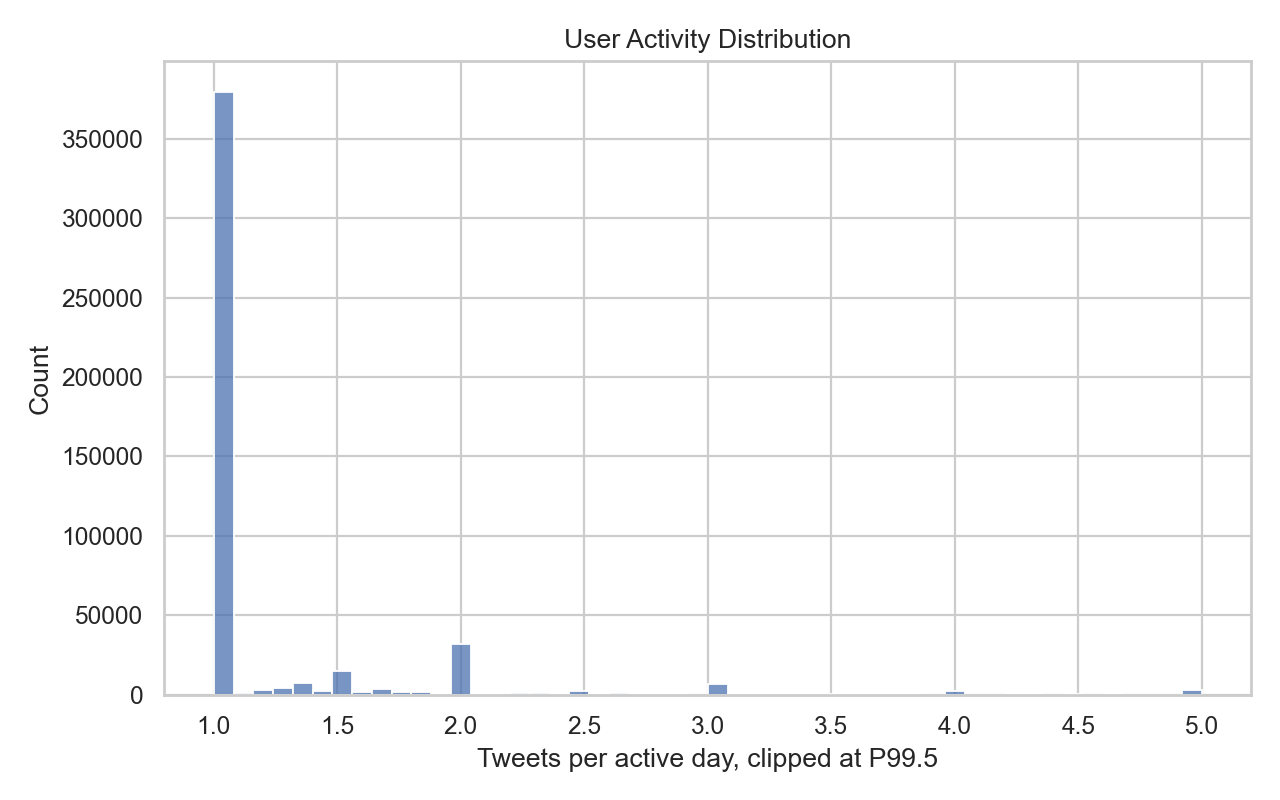

**02_textual_usability_risk_distribution.png**

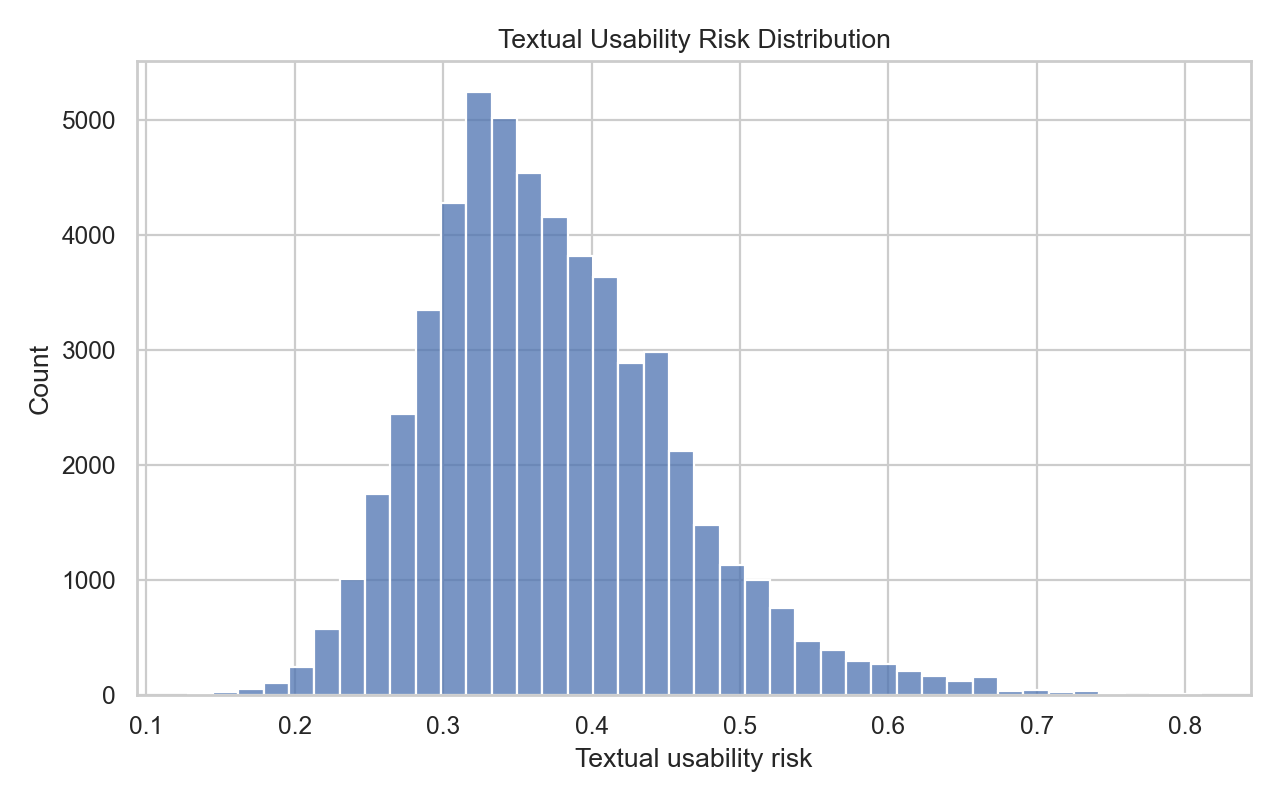

**03_location_confidence_distribution.png**

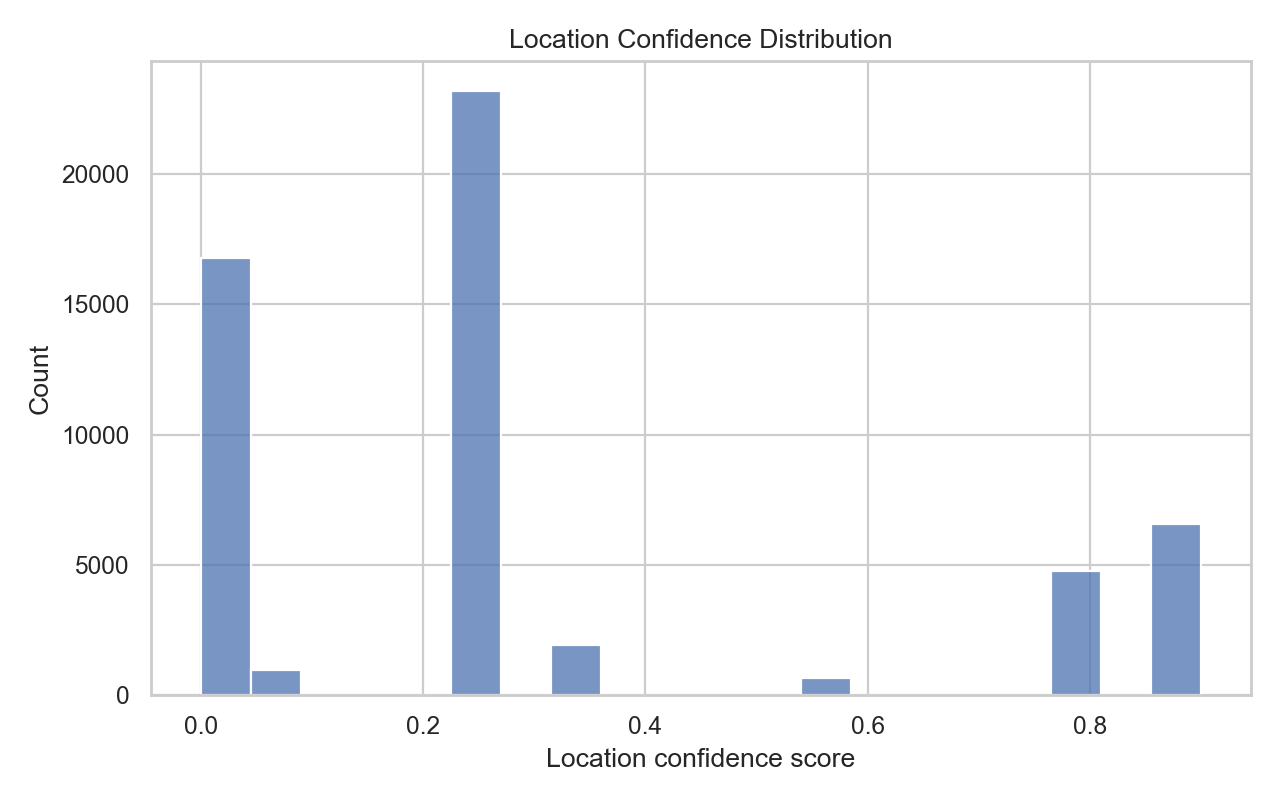

**04_temporal_volume_and_event_windows.png**

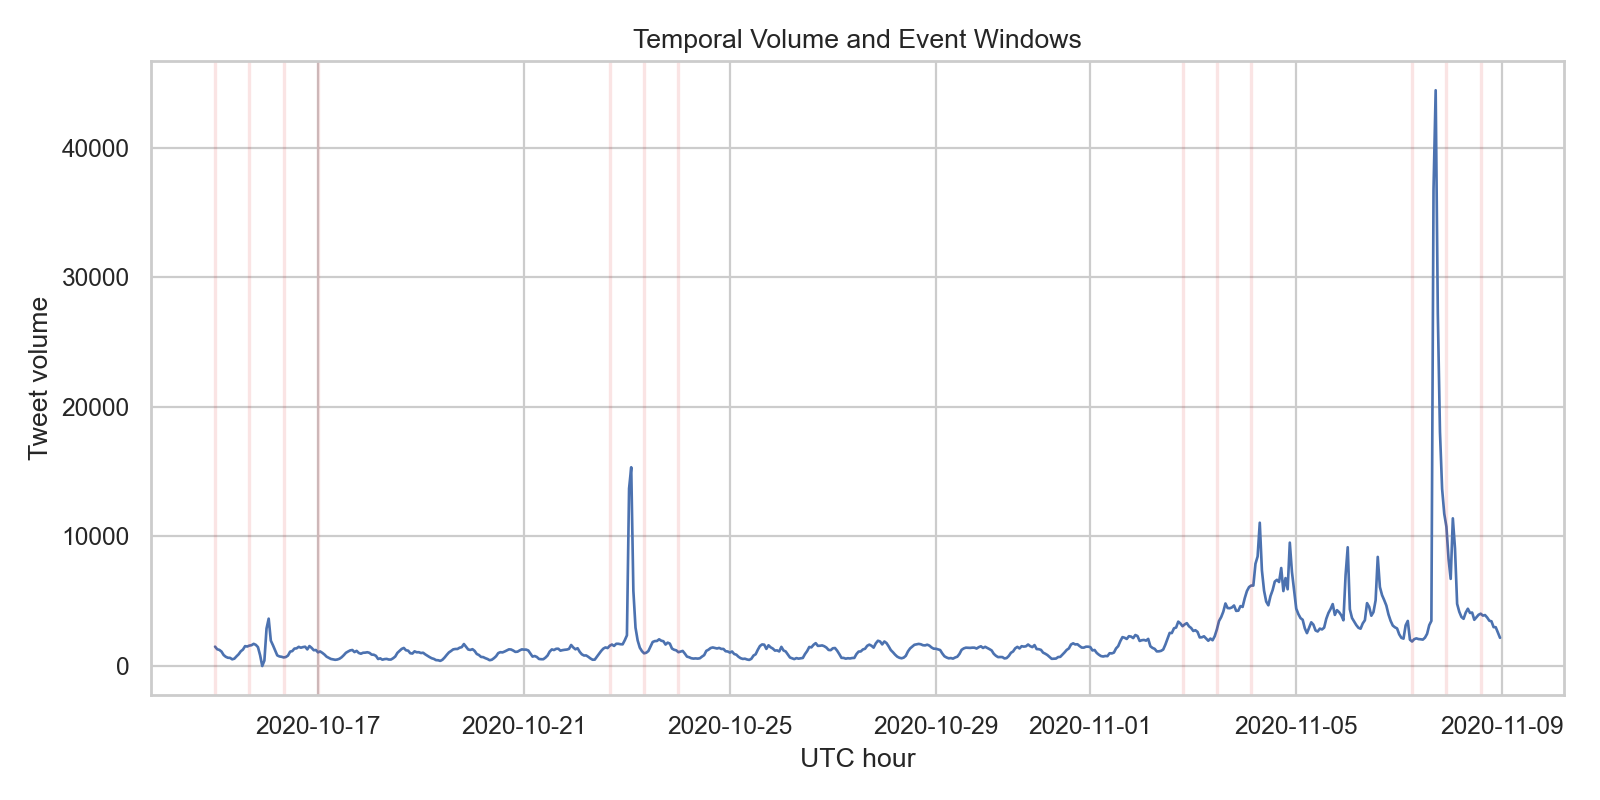

**05_duplicate_amplification_distribution.png**

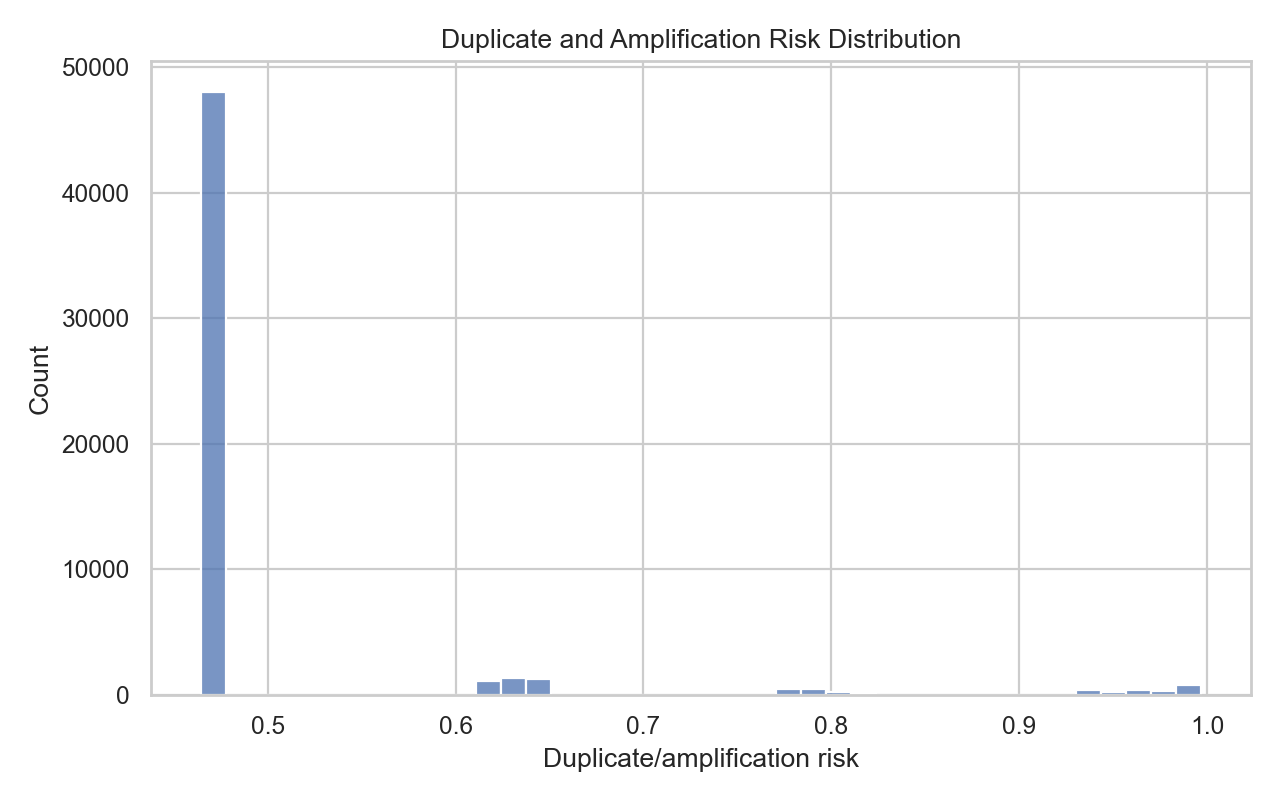

**06_criterion_risk_heatmap.png**

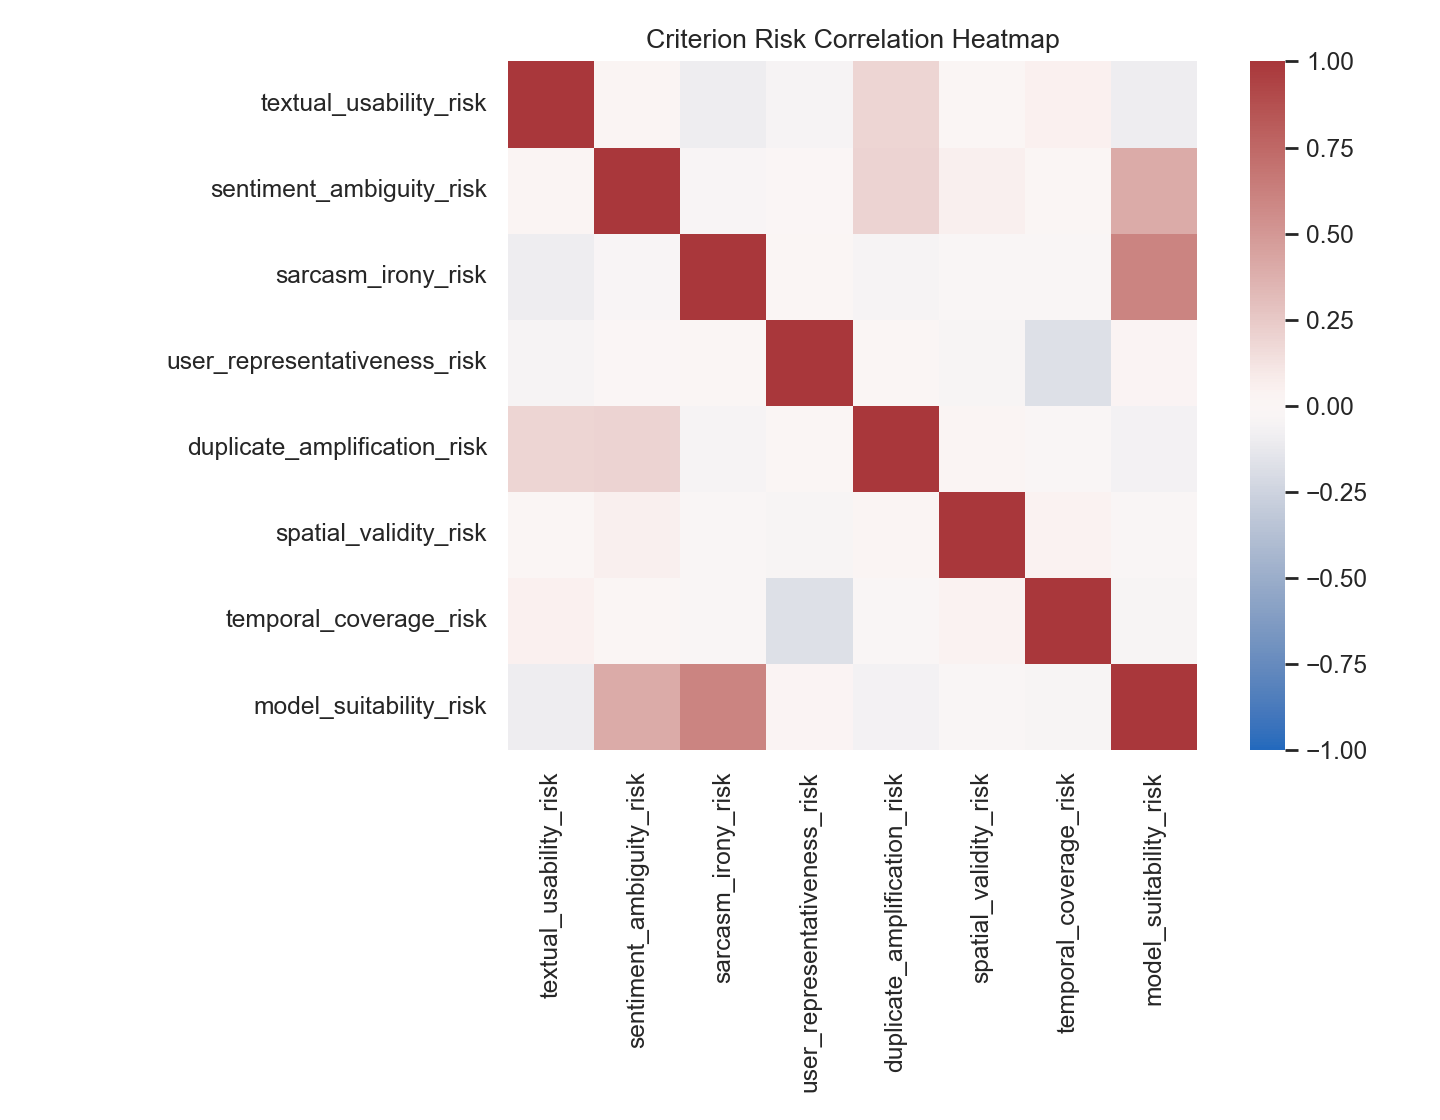

In [18]:
for relative_path in [
    'output/graphs/phase2_5/01_user_activity_distribution.png',
    'output/graphs/phase2_5/02_textual_usability_risk_distribution.png',
    'output/graphs/phase2_5/03_location_confidence_distribution.png',
    'output/graphs/phase2_5/04_temporal_volume_and_event_windows.png',
    'output/graphs/phase2_5/05_duplicate_amplification_distribution.png',
    'output/graphs/phase2_5/06_criterion_risk_heatmap.png',
]:
    path = ROOT / relative_path
    if path.exists():
        display(Markdown(f'**{Path(relative_path).name}**'))
        display(Image(filename=str(path)))

## Transfer note

Use `docs/PHASE2_5_NOTEBOOK_TO_PIPELINE_GUIDE.md` to move this notebook into production Python modules. The future production runner should become the authoritative execution path; this notebook should remain a fast evaluation and explanation artifact.